In [136]:
import warnings
warnings.filterwarnings("ignore")

In [137]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns

In [138]:
from collections import defaultdict

In [139]:
import matplotlib.pyplot as plt

In [140]:
from scipy.sparse import csr_matrix

In [141]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [142]:
from implicit.als import AlternatingLeastSquares

## 1. Configurations

In [143]:
RANDOM_STATE = 42

TOP_K = 10

# Number of candidates generated internally by recommenders.
CANDIDATE_K = 100

# Number of recommendations generated during broader candidate-generation experiments.
RETRIEVAL_K = 100

# Minimum number of interactions required for a user to participate in collaborative-filtering evaluation.
MIN_USER_INTERACTIONS = 2

# Recency decay.
RECENCY_HALF_LIFE_DAYS = 7

# Directory containing outputs from previous notebooks.
PROCESSED_DIR = Path("../artifacts/processed")

# Directory for baseline model outputs.
BASELINE_DIR = Path("../artifacts/baselines")

BASELINE_DIR.mkdir(parents=True,exist_ok=True)

## 2. Load Processed Datasets

In [144]:
consumer = pd.read_parquet(PROCESSED_DIR / "consumer_clean.parquet")

content = pd.read_parquet(PROCESSED_DIR / "content_clean.parquet")

print("Consumer shape:", consumer.shape)

print("Content shape:", content.shape)

Consumer shape: (72312, 11)
Content shape: (3122, 16)


## 3. Standaridize Columns

In [145]:
consumer.columns = (consumer.columns.str.strip().str.lower())

content.columns = (content.columns.str.strip().str.lower())

## 4. Convert Timestamps

In [146]:
consumer["event_datetime"] = pd.to_datetime(consumer["event_timestamp"],unit="s", utc=True)

content["content_event_datetime"] = pd.to_datetime(content["event_timestamp"], unit="s",utc=True)

consumer = consumer.sort_values("event_datetime").reset_index(drop=True)

content = content.sort_values("content_event_datetime").reset_index(drop=True)

## 5. Interaction Weights

In [147]:
INTERACTION_WEIGHTS = {"content_watched": 1.0, "content_liked": 2.0, "content_saved": 3.0,"content_followed": 4.0,"content_commented_on": 5.0}

consumer["interaction_weight"] = (consumer["interaction_type"].map(INTERACTION_WEIGHTS).fillna(0.0))

consumer["is_positive"] = (consumer["interaction_weight"] > 0).astype(int)

## 6. Determine Available Articles

In [148]:
# Sort lifecycle events chronologically.
content_sorted = content.sort_values(["item_id", "content_event_datetime"])

# Keep the latest known lifecycle state for every article.
latest_content_state = (content_sorted.groupby("item_id").tail(1).copy())

# Article is available only if its latest state is "content_present".
latest_content_state["is_available"] = (latest_content_state["interaction_type"].eq("content_present"))

available_items = set(latest_content_state.loc[latest_content_state["is_available"],"item_id"])

pulled_items = set(latest_content_state.loc[~latest_content_state["is_available"],"item_id"])

print("Available articles:", len(available_items))

print("Pulled-out articles:",len(pulled_items))

Available articles: 2983
Pulled-out articles: 74


## 7. English Article Set

In [149]:
english_items = set(content.loc[content["language"].astype(str).str.lower().eq("en"),"item_id"])

print("English articles:", len(english_items))

English articles: 2218


## 8. Temporal Train / Test Split

In [150]:
# Sort interactions chronologically.
consumer_sorted = consumer.sort_values(["consumer_id", "event_datetime"]).copy()

# Number interactions per user.
user_event_counts = (consumer_sorted.groupby("consumer_id").size())

# Users having at least two interactions can contribute one interaction to test while retaining history for training.
eligible_users = user_event_counts[user_event_counts >= MIN_USER_INTERACTIONS].index

eligible_data = consumer_sorted[consumer_sorted["consumer_id"].isin(eligible_users)].copy()

# Last interaction of each eligible user becomes test data.
test_indices = (eligible_data.groupby("consumer_id").tail(1).index)

test_df = eligible_data.loc[test_indices].copy()

# Everything before the held-out event becomes training data.
train_df = eligible_data.drop(test_indices).copy()

print("Train interactions:", len(train_df))

print("Test interactions:", len(test_df))

print("Test users:", test_df["consumer_id"].nunique())

Train interactions: 70417
Test interactions: 1715
Test users: 1715


## 9. Remove unavailable training items

In [151]:
train_items = set(train_df["item_id"].unique())

train_available_items = (train_items & available_items)

print("Training items:", len(train_items))

print("Training + currently available items:", len(train_available_items))

Training items: 2980
Training + currently available items: 2911


## 10. Build Seen Item Dictionary

In [152]:
user_seen_items = (train_df.groupby("consumer_id")["item_id"].apply(set).to_dict())

def get_seen_items(user_id):
    """
    Return articles already seen by a user in the training period.
    """
    return user_seen_items.get(user_id, set())

## 11. Test ground truth

In [153]:
test_truth = (test_df.groupby("consumer_id")["item_id"].apply(set).to_dict())

print("Users with test targets:", len(test_truth))

Users with test targets: 1715


# Baseline 1 : Global Popularity

In [154]:
global_popularity = (train_df.groupby("item_id").agg(interaction_count=("consumer_id","size"),unique_users=("consumer_id","nunique"),total_weight=("interaction_weight","sum")).reset_index())

global_popularity = (global_popularity.sort_values(["unique_users","total_weight","interaction_count"],ascending=False).reset_index(drop=True))


global_popular_items = (global_popularity["item_id"].tolist())

### Popularity Recommender

In [155]:
def recommend_popular(user_id, k=10):
    """
    Recommend globally popular articles.
    Filters:
        - already-seen articles
        - unavailable articles
    """
    seen = get_seen_items(user_id)
    recommendations = []
    for item_id in global_popular_items:
        if item_id in seen:
            continue
        if item_id not in available_items:
            continue
        recommendations.append(item_id)
        if len(recommendations) >= k:
            break
    return recommendations

In [156]:
# Test
example_user = test_df["consumer_id"].iloc[0]
recommend_popular(example_user,10)

[-133139342397538859,
 -6783772548752091658,
 7507067965574797372,
 -4029704725707465084,
 -6843047699859121724,
 8224860111193157980,
 -1297580205670251233,
 -2358756719610361882,
 1356221992133852808,
 2581138407738454418]

# Baseline 2 — Weighted Popularity

In [157]:
weighted_popularity = (train_df.groupby("item_id").agg(weighted_score=("interaction_weight","sum"),unique_users=("consumer_id","nunique")).reset_index())

weighted_popularity["score"] = (weighted_popularity["weighted_score"] * np.log1p(weighted_popularity["unique_users"]))

weighted_popularity = (weighted_popularity.sort_values("score", ascending=False).reset_index(drop=True))

weighted_popular_items = (weighted_popularity["item_id"].tolist())

### Recommend Weighted Popularity

In [158]:
def recommend_weighted_popularity(user_id, k=10):
    seen = get_seen_items(user_id)
    recommendations = []
    for item_id in weighted_popular_items:
        if item_id in seen:
            continue
        if item_id not in available_items:
            continue
        recommendations.append(item_id)
        if len(recommendations) >= k:
            break
    return recommendations

# Baseline 3 — Recent Trending Articles

In [159]:
# Aggregate recent article engagement.
recent_stats = (train_df.groupby("item_id").agg(last_interaction = ("event_datetime","max"),recent_interactions=("item_id", "size"), recent_unique_users=("consumer_id","nunique"),recent_weight=("interaction_weight", "sum")).reset_index())

reference_time = train_df["event_datetime"].max()

recent_stats["age_days"] = ((reference_time - recent_stats["last_interaction"]).dt.total_seconds() / 86400).clip(lower=0)

# Exponential freshness decay.
recent_stats["freshness"] = np.exp(-np.log(2) * recent_stats["age_days"] / RECENCY_HALF_LIFE_DAYS)

# Trending score combines engagement with freshness.
recent_stats["trending_score"] = (np.log1p(recent_stats["recent_unique_users"]) * np.log1p(recent_stats["recent_weight"]) * recent_stats["freshness"])

recent_stats = (recent_stats.sort_values("trending_score", ascending=False).reset_index(drop=True))

trending_items = (recent_stats["item_id"].tolist())

### Trending Recommender

In [160]:
def recommend_trending(user_id, k=10):
    seen = get_seen_items(user_id)
    recommendations = []
    for item_id in trending_items:
        if item_id in seen:
            continue
        if item_id not in available_items:
            continue
        recommendations.append(item_id)
        if len(recommendations) >= k:
            break
    return recommendations

# Baseline 4 — Personalized Popularity By User Country

In [161]:
country_popularity = (train_df.groupby(["country", "item_id"]).agg(country_interactions=("item_id", "size"), country_users=("consumer_id", "nunique"), country_weight=("interaction_weight", "sum")).reset_index())

country_popularity["score"] = (np.log1p(country_popularity["country_users"]) * np.log1p(country_popularity["country_weight"]))

country_popularity = (country_popularity.sort_values(["country", "score"],ascending=[True, False]))

In [162]:
country_item_rankings = {}

for country, group in country_popularity.groupby("country"):
    country_item_rankings[country] = group["item_id"].tolist()

In [163]:
user_country = (train_df.groupby("consumer_id")["country"].agg(lambda x: x.dropna().mode().iloc[0] if not x.dropna().empty else "unknown").to_dict())

### Recommend Country Popularity

In [164]:
def recommend_country_popularity(user_id, k=10):
    country = user_country.get(user_id, "unknown")
    ranking = country_item_rankings.get(country, global_popular_items)
    seen = get_seen_items(user_id)
    recommendations = []
    for item_id in ranking:
        if item_id in seen:
            continue
        if item_id not in available_items:
            continue
        recommendations.append(item_id)
        if len(recommendations) >= k:
            break
    return recommendations

# Baseline 5 — TF-IDF Content Based Recommender

In [165]:
article_catalog = (content.drop_duplicates(subset=["item_id"]).copy())

# Only English articles are eligible for content-based
# recommendation according to the project requirement.
article_catalog = article_catalog[article_catalog["language"].astype(str).str.lower().eq("en")].copy()

# Only currently available articles.
article_catalog = article_catalog[article_catalog["item_id"].isin(available_items)].copy()

# Build article text.
article_catalog["article_text"] = (article_catalog["title"].fillna("").astype(str) + " " + article_catalog["text_description"].fillna("").astype(str))

### TF IDF Matrix

In [166]:
tfidf_vectorizer = TfidfVectorizer(max_features=20000, stop_words="english", ngram_range=(1, 2), min_df=2, sublinear_tf=True)

tfidf_matrix = (tfidf_vectorizer.fit_transform(article_catalog["article_text"]))

print("TF-IDF matrix:", tfidf_matrix.shape)

TF-IDF matrix: (2166, 20000)


In [167]:
tfidf_item_to_index = {item_id: idx for idx, item_id in enumerate(article_catalog["item_id"])}

### TF IDF Similarity

In [168]:
def recommend_similar_tfidf(item_id, k=10):
    """
    Recommend articles similar to a given article using TF-IDF cosine similarity.
    """
    if item_id not in tfidf_item_to_index:
        return []
    idx = tfidf_item_to_index[item_id]
    similarities = cosine_similarity(tfidf_matrix[idx], tfidf_matrix).ravel()
    # Highest similarity first.
    candidate_indices = np.argsort(similarities)[::-1]
    recommendations = []
    for candidate_idx in candidate_indices:
        candidate_item = (article_catalog.iloc[candidate_idx]["item_id"])
        # Don't recommend itself.
        if candidate_item == item_id:
            continue
        recommendations.append(candidate_item)
        if len(recommendations) >= k:
            break
    return recommendations

### User Level TF-IDF Recommender

In [169]:
def recommend_tfidf_for_user(user_id, k=10):
    seen = get_seen_items(user_id)
    profile_indices = [tfidf_item_to_index[item_id] for item_id in seen if item_id in tfidf_item_to_index]
    if not profile_indices:
        return recommend_popular(user_id, k)
    user_profile = (tfidf_matrix[profile_indices].mean(axis=0))
    similarities = cosine_similarity(user_profile, tfidf_matrix).ravel()
    candidate_indices = np.argsort(similarities)[::-1]
    recommendations = []
    for idx in candidate_indices:
        item_id = (article_catalog.iloc[idx]["item_id"])
        if item_id in seen:
            continue
        if item_id not in available_items:
            continue
        recommendations.append(item_id)
        if len(recommendations) >= k:
            break
    return recommendations

In [170]:
print("Article catalog:", article_catalog.shape)

print("TF-IDF matrix:", tfidf_matrix.shape)

print("TF-IDF mapping:", len(tfidf_item_to_index))

print("Available items:", len(available_items))

Article catalog: (2166, 18)
TF-IDF matrix: (2166, 20000)
TF-IDF mapping: 2166
Available items: 2983


# Baseline 6 — Item-Item Collaborative Filtering

In [171]:
user_item = (train_df.groupby(["consumer_id", "item_id"]).agg(interaction_weight=("interaction_weight", "sum")).reset_index())

# Map IDs to matrix indices.
user_ids = (user_item["consumer_id"].unique())

item_ids = (user_item["item_id"].unique())

user_to_index = {user_id: idx for idx, user_id in enumerate(user_ids)}

item_to_index = {item_id: idx for idx, item_id in enumerate(item_ids)}

index_to_user = {idx: user_id for user_id, idx in user_to_index.items()}

index_to_item = {idx: item_id for item_id, idx in item_to_index.items()}

### Create Matrix

In [172]:
rows = (user_item["consumer_id"].map(user_to_index))

cols = (user_item["item_id"].map(item_to_index))

values = (user_item["interaction_weight"].astype(float))

user_item_matrix = csr_matrix((values, (rows, cols)), shape=(len(user_to_index), len(item_to_index)))

print("User-item matrix shape:", user_item_matrix.shape)

print("Non-zero interactions:", user_item_matrix.nnz)

User-item matrix shape: (1715, 2980)
Non-zero interactions: 39401


### Item Item Similarity

In [173]:
item_user_matrix = (user_item_matrix.T)

item_similarity = cosine_similarity(item_user_matrix, dense_output=False)

print("Item similarity matrix:", item_similarity.shape)

Item similarity matrix: (2980, 2980)


### Item CF Recommender

In [174]:
def recommend_item_cf(user_id, k=10):
    """
    Recommend articles using item-item collaborative filtering.
    """
    if user_id not in user_to_index:
        return recommend_popular(user_id,k)
    user_idx = user_to_index[user_id]
    user_vector = (user_item_matrix[user_idx])
    # Scores = user interaction weights × item similarity.
    scores = (user_vector @ item_similarity)
    scores = np.asarray(scores.todense()).ravel()
    # Rank candidate items.
    ranked_indices = np.argsort(scores)[::-1]
    seen = get_seen_items(user_id)
    recommendations = []
    for idx in ranked_indices:
        item_id = index_to_item[idx]
        if item_id in seen:
            continue
        if item_id not in available_items:
            continue
        recommendations.append(item_id)
        if len(recommendations) >= k:
            break
    return recommendations

# Baseline 7 — Implicit ALS

In [175]:
als_matrix = user_item_matrix.copy()

print("ALS matrix:", als_matrix.shape)

ALS matrix: (1715, 2980)


In [176]:
# Train
als_model = AlternatingLeastSquares(factors=64, regularization=0.01, iterations=30,random_state=RANDOM_STATE)

als_model.fit(als_matrix)

100%|██████████| 30/30 [00:00<00:00, 73.17it/s]


### ALS Recommender

In [177]:
def recommend_als(user_id, k=10, filter_seen=True):
    """
    Generate personalized recommendations using implicit ALS.
    """
    if user_id not in user_to_index:
        return recommend_popular(user_id, k)
    user_idx = user_to_index[user_id]
    item_indices, scores = (als_model.recommend(userid=user_idx, user_items=als_matrix[user_idx], N=CANDIDATE_K, filter_already_liked_items=filter_seen))
    recommendations = []
    for item_idx, score in zip(item_indices, scores):
        item_id = index_to_item[int(item_idx)]
        if item_id not in available_items:
            continue
        recommendations.append((item_id, float(score)))
        if len(recommendations) >= k:
            break
    return recommendations

### Clean ALS Output

In [178]:
def recommend_als_items(user_id, k=10):
    results = recommend_als(user_id, k)
    return [item_id for item_id, score in results]

### Inspect ALS Recommendations

In [179]:
example_user = (test_df["consumer_id"].iloc[0])
als_recommendations = (recommend_als(example_user, 10))
als_recommendations

[(3149164017776669829, 0.5940642952919006),
 (-8518096793350810174, 0.5841652154922485),
 (2072448887839540892, 0.5175842642784119),
 (-5570129644089964821, 0.4526847302913666),
 (-6783772548752091658, 0.4223748445510864),
 (1356221992133852808, 0.40046995878219604),
 (-6654470039478316910, 0.3977648913860321),
 (-4333957157636611418, 0.3749291002750397),
 (-133139342397538859, 0.3239893615245819),
 (7526364197140419661, 0.3239789605140686)]

# Baseline 8 — Hybrid Popularity + Trending

In [180]:
popularity_scores = (global_popularity.set_index("item_id")["unique_users"].to_dict())

trending_scores = (recent_stats.set_index("item_id")["trending_score"].to_dict())

### Normalize Scores

In [181]:
def normalize_scores(scores):
    """
    Min-max normalize dictionary scores.
    """
    if not scores:
        return {}
    values = np.array(list(scores.values()), dtype=float)
    min_value = values.min()
    max_value = values.max()
    if max_value == min_value:
        return {key: 1.0 for key in scores}
    return {key: (value - min_value) / (max_value - min_value) for key, value in scores.items()}

popularity_scores_norm = normalize_scores(popularity_scores)

trending_scores_norm = normalize_scores(trending_scores)

### Recommend Popularity Treading

In [182]:
def recommend_popularity_trending(user_id, k=10, popularity_weight=0.5, trending_weight=0.5):
    seen = get_seen_items(user_id)
    candidate_items = (set(popularity_scores_norm) | set(trending_scores_norm))
    scored_items = []
    for item_id in candidate_items:
        if item_id in seen:
            continue
        if item_id not in available_items:
            continue
        score = (popularity_weight * popularity_scores_norm.get(item_id, 0) + trending_weight *
            trending_scores_norm.get(item_id, 0))
        scored_items.append((item_id, score))

    scored_items.sort(key=lambda x: x[1], reverse=True)

    return [item_id for item_id, score in scored_items[:k]]

### Hybrid ALS + Content + Popularity

In [183]:
def get_als_scores(user_id, n=100):
    if user_id not in user_to_index:
        return {}
    user_idx = user_to_index[user_id]
    item_indices, scores = (als_model.recommend(userid=user_idx, user_items=als_matrix[user_idx], N=n, filter_already_liked_items=True))

    result = {}

    for idx, score in zip(item_indices, scores):
        item_id = index_to_item[int(idx)]

        if item_id in available_items:
            result[item_id] = float(score)

    return result

### Semantic & TF-IDF User Score

In [184]:
def get_tfidf_scores_for_user(user_id):
    seen = get_seen_items(user_id)
    profile_indices = [tfidf_item_to_index[item] for item in seen if item in tfidf_item_to_index]
    if not profile_indices:
        return {}
    user_profile = (tfidf_matrix[profile_indices].mean(axis=0))
    similarities = cosine_similarity(user_profile, tfidf_matrix).ravel()
    result = {}
    for idx, similarity in enumerate(similarities):
        item_id = (article_catalog.iloc[idx]["item_id"])
        if item_id in seen:
            continue
        if item_id not in available_items:
            continue
        result[item_id] = float(similarity)
    return result

### Hybrid Recommender

In [185]:
def recommend_hybrid(user_id, k=10, als_weight=0.50, tfidf_weight=0.30, popularity_weight=0.20):
    """
    Simple hybrid baseline.
    Combines:
        ALS
        TF-IDF content similarity
        Global popularity
    """
    als_scores = get_als_scores(user_id, n=CANDIDATE_K)
    tfidf_scores = (get_tfidf_scores_for_user(user_id))
    # Restrict TF-IDF dictionary to top candidates.
    tfidf_scores = dict(sorted(tfidf_scores.items(), key=lambda x: x[1], reverse=True)[:CANDIDATE_K])
    candidate_items = (set(als_scores) | set(tfidf_scores))
    seen = get_seen_items(user_id)
    scored_items = []
    for item_id in candidate_items:
        if item_id in seen:
            continue
        if item_id not in available_items:
            continue
        score = (als_weight * als_scores.get(item_id, 0) + tfidf_weight * tfidf_scores.get(item_id,0) + popularity_weight * popularity_scores_norm.get(item_id, 0))
        scored_items.append((item_id,score))
    scored_items.sort(key=lambda x: x[1], reverse=True)
    return scored_items[:k]

### Generic Recommender Interface

In [186]:
RECOMMENDERS = {"Popularity": lambda user_id: recommend_popular(user_id, TOP_K),"WeightedPopularity": lambda user_id: recommend_weighted_popularity(user_id,TOP_K),"Trending":
lambda user_id: recommend_trending(user_id, TOP_K), "CountryPopularity": lambda user_id: recommend_country_popularity(user_id, TOP_K), "TFIDF": lambda user_id: recommend_tfidf_for_user(user_id, TOP_K), "ItemCF": lambda user_id: recommend_item_cf(user_id, TOP_K), "ALS": lambda user_id: recommend_als_items(user_id, TOP_K), "PopularityTrending": lambda user_id: recommend_popularity_trending(user_id, TOP_K), "Hybrid": lambda user_id: [item_id for item_id, score in recommend_hybrid(user_id, TOP_K)]}

# Evaluation Metrics

## 1. Precision@K

In [187]:
def precision_at_k(recommendations, ground_truth, k=10):
    recommendations = (recommendations[:k])
    if not recommendations:
        return 0.0
    hits = sum(item in ground_truth for item in recommendations)
    return hits / k

## 2. Recall@K

In [188]:
def recall_at_k(recommendations, ground_truth, k=10):
    if not ground_truth:
        return 0.0
    recommendations = (recommendations[:k])
    hits = sum(item in ground_truth for item in recommendations)
    return hits / len(ground_truth)

## 3. Hit Rate

In [189]:
def hit_rate_at_k(recommendations, ground_truth, k=10):
    recommendations = (recommendations[:k])
    return float(any(item in ground_truth for item in recommendations))

## 4. NDCG@K

In [190]:
def ndcg_at_k(recommendations, ground_truth, k=10):
    recommendations = (recommendations[:k])
    dcg = 0.0
    for rank, item in enumerate(recommendations, start=1):
        if item in ground_truth:
            dcg += (1 / np.log2(rank + 1))
    ideal_hits = min(len(ground_truth), k)
    if ideal_hits == 0:
        return 0.0
    idcg = sum(1 / np.log2(rank + 1) for rank in range(1, ideal_hits + 1))
    return dcg / idcg

## 5. MAP@K

In [191]:
def average_precision_at_k(recommendations, ground_truth, k=10):
    recommendations = (recommendations[:k])
    if not ground_truth:
        return 0.0
    hits = 0
    precision_sum = 0.0
    for rank, item in enumerate(recommendations, start=1):
        if item in ground_truth:
            hits += 1
            precision_sum += (hits / rank)
    return (precision_sum / min(len(ground_truth), k))

## Evaluate One Model

In [192]:
def evaluate_recommender(recommender, test_truth, k=10):
    precisions = []
    recalls = []
    hits = []
    ndcgs = []
    maps = []
    recommendation_catalog = set()
    for user_id, truth in test_truth.items():
        try:
            recommendations = (recommender(user_id))
        except Exception:
            recommendations = []
        recommendation_catalog.update(recommendations)
        precisions.append(precision_at_k(recommendations, truth, k))
        recalls.append(recall_at_k(recommendations, truth, k))
        hits.append(hit_rate_at_k(recommendations,truth, k))
        ndcgs.append(ndcg_at_k(recommendations, truth, k))
        maps.append(average_precision_at_k(recommendations, truth, k))
    return {"Precision@K": np.mean(precisions), "Recall@K": np.mean(recalls), "HitRate@K": np.mean(hits), "NDCG@K": np.mean(ndcgs), "MAP@K": np.mean(maps), "Coverage@K": len(recommendation_catalog)}

In [193]:
def evaluate_recommender(recommender, test_truth,k=10):
    precisions = []
    recalls = []
    hits = []
    ndcgs = []
    maps = []
    recommendation_catalog = set()
    failed_users = 0
    for user_id, truth in test_truth.items():
        try:
            recommendations = recommender(user_id)
        except Exception as e:
            failed_users += 1
            print(f"Recommendation failed " f"for user {user_id}: {e}")
            recommendations = []
        recommendation_catalog.update(recommendations)
        precisions.append(precision_at_k(recommendations, truth, k))
        recalls.append(recall_at_k(recommendations, truth, k))
        hits.append(hit_rate_at_k(recommendations, truth, k))
        ndcgs.append(ndcg_at_k(recommendations, truth, k))
        maps.append(average_precision_at_k(recommendations, truth, k))

    return {"Precision@K": np.mean(precisions), "Recall@K": np.mean(recalls), "HitRate@K": np.mean(hits), "NDCG@K": np.mean(ndcgs), "MAP@K": np.mean(maps), "Coverage@K": len(recommendation_catalog), "FailedUsers": failed_users}

## Run All Baselines

In [194]:
results = []
for model_name, recommender in RECOMMENDERS.items():
    print(f"Evaluating {model_name}...")
    metrics = evaluate_recommender(recommender, test_truth, TOP_K)
    metrics["Model"] = model_name
    results.append(metrics)
results_df = pd.DataFrame(results)
results_df = results_df[["Model", "Precision@K", "Recall@K", "HitRate@K", "NDCG@K", "MAP@K","Coverage@K"]]
results_df = (results_df.sort_values("NDCG@K", ascending=False).reset_index(drop=True))
display(results_df)

Evaluating Popularity...
Evaluating WeightedPopularity...
Evaluating Trending...
Evaluating CountryPopularity...
Evaluating TFIDF...
Recommendation failed for user -9223121837663643404: np.matrix is not supported. Please convert to a numpy array with np.asarray. For more information see: https://numpy.org/doc/stable/reference/generated/numpy.matrix.html
Recommendation failed for user -9212075797126931087: np.matrix is not supported. Please convert to a numpy array with np.asarray. For more information see: https://numpy.org/doc/stable/reference/generated/numpy.matrix.html
Recommendation failed for user -9207251133131336884: np.matrix is not supported. Please convert to a numpy array with np.asarray. For more information see: https://numpy.org/doc/stable/reference/generated/numpy.matrix.html
Recommendation failed for user -9199575329909162940: np.matrix is not supported. Please convert to a numpy array with np.asarray. For more information see: https://numpy.org/doc/stable/reference/gen

,Model,Precision@K,Recall@K,HitRate@K,NDCG@K,MAP@K,Coverage@K
0,Trending,0.011195,0.111953,0.111953,0.086904,0.079322,26
1,PopularityTrending,0.011195,0.111953,0.111953,0.085597,0.077811,26
2,CountryPopularity,0.010204,0.102041,0.102041,0.053656,0.037980,100
3,ALS,0.008571,0.085714,0.085714,0.043834,0.031169,1004
4,Popularity,0.009854,0.098542,0.098542,0.042207,0.024942,30
5,WeightedPopularity,0.009504,0.095044,0.095044,0.037741,0.021362,26
6,ItemCF,0.002682,0.026822,0.026822,0.011150,0.006596,2206
7,Hybrid,0.001808,0.018076,0.018076,0.009546,0.006860,121
8,TFIDF,0.001983,0.019825,0.019825,0.008897,0.005562,13


## Make Metric Names Explicit

In [195]:
results_df = results_df.rename(columns={
        "Precision@K": f"Precision@{TOP_K}",
        "Recall@K": f"Recall@{TOP_K}",
        "HitRate@K": f"HitRate@{TOP_K}",
        "NDCG@K": f"NDCG@{TOP_K}",
        "MAP@K": f"MAP@{TOP_K}",
        "Coverage@K": f"Coverage@{TOP_K}"
    }
)

display(results_df)

,Model,Precision@10,Recall@10,HitRate@10,NDCG@10,MAP@10,Coverage@10
0,Trending,0.011195,0.111953,0.111953,0.086904,0.079322,26
1,PopularityTrending,0.011195,0.111953,0.111953,0.085597,0.077811,26
2,CountryPopularity,0.010204,0.102041,0.102041,0.053656,0.037980,100
3,ALS,0.008571,0.085714,0.085714,0.043834,0.031169,1004
4,Popularity,0.009854,0.098542,0.098542,0.042207,0.024942,30
5,WeightedPopularity,0.009504,0.095044,0.095044,0.037741,0.021362,26
6,ItemCF,0.002682,0.026822,0.026822,0.011150,0.006596,2206
7,Hybrid,0.001808,0.018076,0.018076,0.009546,0.006860,121
8,TFIDF,0.001983,0.019825,0.019825,0.008897,0.005562,13


## 6. Add Novelty

In [196]:
item_popularity_probability = (train_df.groupby("item_id").size() / len(train_df)).to_dict()

In [197]:
def novelty_at_k(recommendations, k=10):
    recommendations = (recommendations[:k])
    if not recommendations:
        return 0.0
    novelty_scores = []
    for item_id in recommendations:
        probability = (item_popularity_probability.get(item_id, 1e-12))
        novelty_scores.append(-np.log2(probability))
    return np.mean(novelty_scores)

### Evaluate Novelty

In [198]:
def evaluate_novelty(recommender, test_users, k=10):
    novelty_values = []
    for user_id in test_users:
        recommendations = (recommender(user_id))
        novelty_values.append(novelty_at_k(recommendations, k))
    return np.mean(novelty_values)

## 7. Add Seen Item Violation Rate

In [199]:
def seen_item_violation_rate(recommender, test_users, k=10):
    total_recommendations = 0
    violations = 0
    for user_id in test_users:
        recommendations = (recommender(user_id))
        seen = get_seen_items(user_id)
        for item_id in recommendations:
            total_recommendations += 1
            if item_id in seen:
                violations += 1
    if total_recommendations == 0:
        return 0.0
    return (violations / total_recommendations)

## 8. Availability violation

In [200]:
def availability_violation_rate(recommender, test_users, k=10):
    total = 0
    violations = 0
    for user_id in test_users:
        recommendations = (recommender(user_id))
        for item_id in recommendations:
            total += 1
            if item_id not in available_items:
                violations += 1
    if total == 0:
        return 0.0
    return violations / total

# Save Baseline Results

In [201]:
results_df.to_csv(BASELINE_DIR / "baseline_results.csv", index=False)
print("Saved:", BASELINE_DIR / "baseline_results.csv")

Saved: ..\artifacts\baselines\baseline_results.csv


## Compare Models Visually

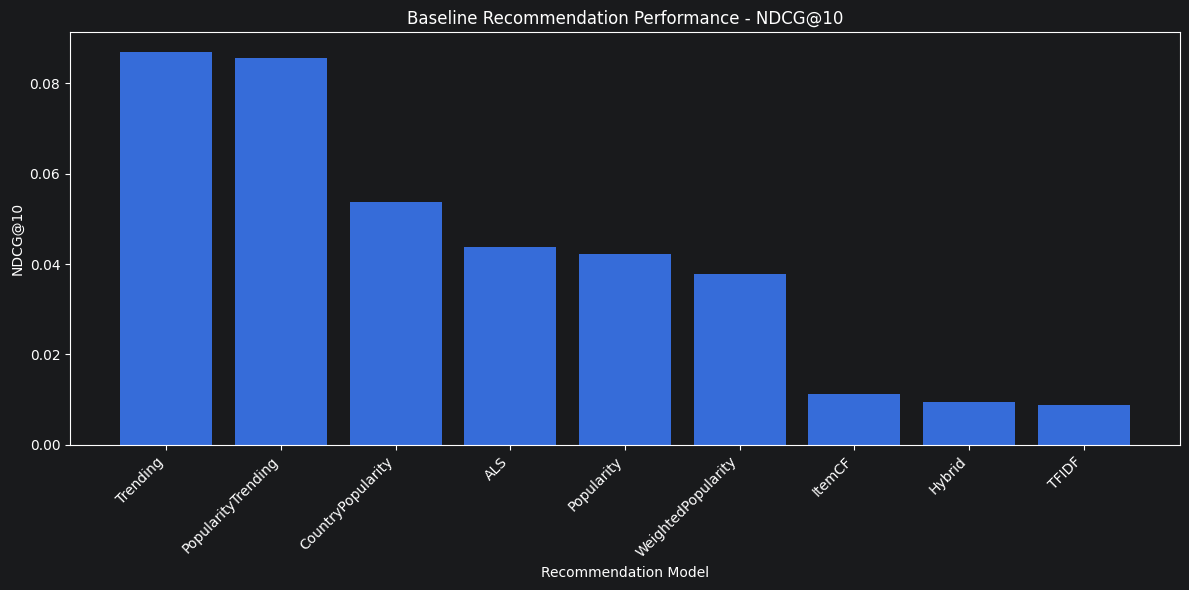

In [202]:
plt.figure(figsize=(12, 6))
plt.bar(results_df["Model"], results_df[f"NDCG@{TOP_K}"])
plt.xlabel("Recommendation Model")
plt.ylabel(f"NDCG@{TOP_K}")
plt.title(f"Baseline Recommendation Performance - NDCG@{TOP_K}")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Compare Recall

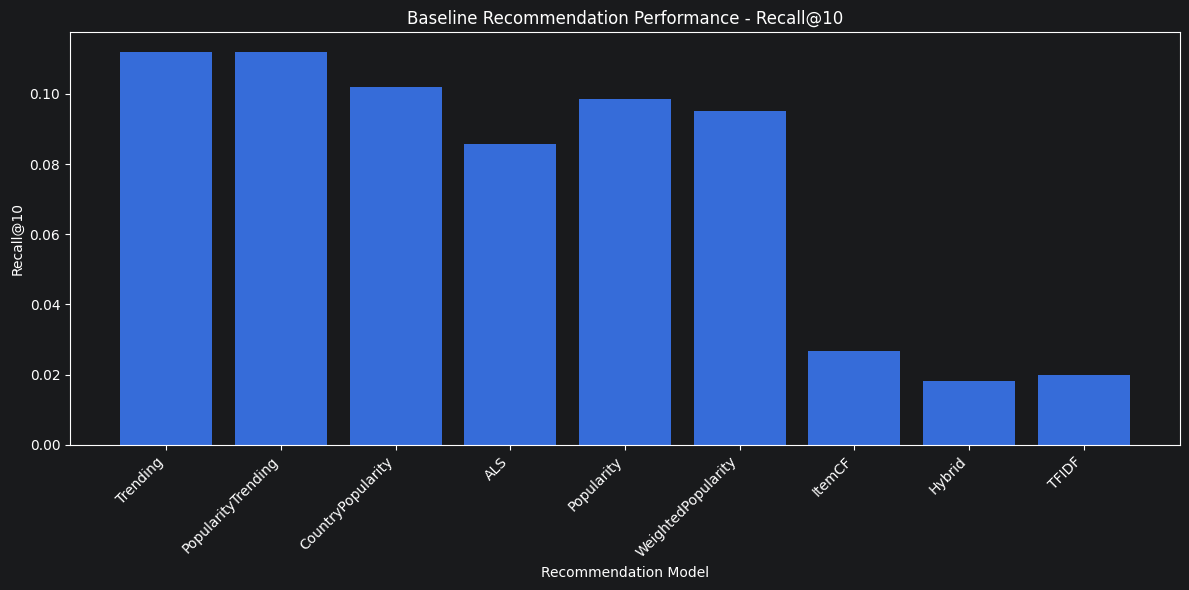

In [203]:
plt.figure(figsize=(12, 6))
plt.bar(results_df["Model"], results_df[f"Recall@{TOP_K}"])
plt.xlabel("Recommendation Model")
plt.ylabel(f"Recall@{TOP_K}")
plt.title(f"Baseline Recommendation Performance - Recall@{TOP_K}")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Baseline Experiment Matrix

In [204]:
ALS_CONFIGS = [{"factors": 32, "regularization": 0.01, "iterations": 20},{"factors": 64,"regularization": 0.01, "iterations": 30}, {"factors": 64, "regularization": 0.05,"iterations": 30},{"factors": 128, "regularization": 0.01, "iterations": 30},{"factors": 128,"regularization": 0.05, "iterations": 50}]

In [205]:
als_experiments = []
for config in ALS_CONFIGS:
    print("Training ALS:", config)
    model = AlternatingLeastSquares(factors=config["factors"],regularization=config["regularization"], iterations=config["iterations"],random_state=RANDOM_STATE)
    model.fit(als_matrix)

Training ALS: {'factors': 32, 'regularization': 0.01, 'iterations': 20}


100%|██████████| 20/20 [00:00<00:00, 74.87it/s]


Training ALS: {'factors': 64, 'regularization': 0.01, 'iterations': 30}


100%|██████████| 30/30 [00:00<00:00, 71.16it/s]


Training ALS: {'factors': 64, 'regularization': 0.05, 'iterations': 30}


100%|██████████| 30/30 [00:00<00:00, 71.29it/s]


Training ALS: {'factors': 128, 'regularization': 0.01, 'iterations': 30}


100%|██████████| 30/30 [00:00<00:00, 71.49it/s]


Training ALS: {'factors': 128, 'regularization': 0.05, 'iterations': 50}


100%|██████████| 50/50 [00:00<00:00, 68.70it/s]


In [206]:
def experiment_recommender(user_id, model=model):
        if user_id not in user_to_index:
            return []
        user_idx = user_to_index[user_id]
        item_indices, scores = (model.recommend(userid=user_idx, user_items=als_matrix[user_idx], N=TOP_K, filter_already_liked_items=True))
        results = []
        for idx in item_indices:
            item_id = index_to_item[int(idx)]
            if item_id in available_items:
                results.append(item_id)
        return results[:TOP_K]

In [207]:
 metrics = evaluate_recommender(experiment_recommender, test_truth, TOP_K)

In [208]:
als_experiments.append({**config, **metrics})

In [209]:
als_experiment_df = pd.DataFrame(als_experiments)

als_experiment_df.to_csv(BASELINE_DIR / "als_hyperparameter_experiments.csv", index=False)

display(als_experiment_df)

,factors,regularization,iterations,Precision@K,Recall@K,HitRate@K,NDCG@K,MAP@K,Coverage@K,FailedUsers
0,128,0.05,50,0.008047,0.080466,0.080466,0.039485,0.027072,1236,0
